In [1]:
import scanpy as sc
import pandas as pd
#import rapids_singlecell as rsc
#import cupy as cp
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.executable)
#print("cupy", cp.__version__)
print("scanpy", sc.__version__)
#print("GPU count:", cp.cuda.runtime.getDeviceCount())
#print(cp.arange(10).sum())


/home/users/z/zhouji/.conda/envs/rsc-gpu/bin/python
scanpy 1.12.2


/tmp/ipykernel_2600808/381363102.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


1. remove parents 
2. check if the age between patient and siblings are comparable 
3. down samples to comparable level
4. for each 22q11 genes, calcualte it's expression in across all cell types, compare between patients and siblings. 
5. based on the co-expression of 22q11 genes, set a cut off value, for cells with low value, we keep it for further analysis, while for cells with high score(i.e., these genes are still expressing in cells), we discard them from downstream analysis these are my tasks, how do I proceed

In [3]:
adata_full=sc.read_h5ad("adata_no_doublet_withanno.h5ad")

In [4]:
# Keep only patients and siblings
mask_ps = adata_full.obs["family_role"].isin(["Patient", "Sibling"])
adata_ps =  adata_full[mask_ps, :].copy()
adata_ps

AnnData object with n_obs × n_vars = 878485 × 36910
    obs: 'counts', 'genes', 'totalReads', 'countedReads', 'mappedReads', 'geneReads', 'exonReads', 'intronReads', 'antisenseReads', 'mitoReads', 'countedMultiGeneReads', 'Saturation', 'mitoProp', 'PCR', 'RT', 'bead_bc', 'sample', 'flags', 'passing_scaleplex', 'assigned_scaleplex', 'sample_group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.07', 'leiden_res_0.50', 'leiden_res_1.00', 'Mono_score', 'CD4+ T_score', 'CD8+ T_score', 'NK_score', 'B cells_score', 'DC_score', 'unconventional T_score', 'Eryth_score', 'HSPC_score', 'ILC_score', 'Platelet_score', 'celltype_l1', 'Unnamed: 0', 'Date of fixation', 'Unnamed: 2', 'sample_id', 'barcode', 'sample_type', 'sample_name', 'diagnosis', 'participant_id', 'age', 'sex', 'ethnic_origin', 'linked_22q_id', 'Type of relatio

In [5]:
# Keep only pairs/families that contain at least one patient and one sibling
sample_meta = (
    adata_ps.obs
    .drop_duplicates("assigned_scaleplex")
    .copy()
)


In [6]:
#remove adata_full to save memory
del adata_full

In [7]:
adata_ps

AnnData object with n_obs × n_vars = 878485 × 36910
    obs: 'counts', 'genes', 'totalReads', 'countedReads', 'mappedReads', 'geneReads', 'exonReads', 'intronReads', 'antisenseReads', 'mitoReads', 'countedMultiGeneReads', 'Saturation', 'mitoProp', 'PCR', 'RT', 'bead_bc', 'sample', 'flags', 'passing_scaleplex', 'assigned_scaleplex', 'sample_group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.07', 'leiden_res_0.50', 'leiden_res_1.00', 'Mono_score', 'CD4+ T_score', 'CD8+ T_score', 'NK_score', 'B cells_score', 'DC_score', 'unconventional T_score', 'Eryth_score', 'HSPC_score', 'ILC_score', 'Platelet_score', 'celltype_l1', 'Unnamed: 0', 'Date of fixation', 'Unnamed: 2', 'sample_id', 'barcode', 'sample_type', 'sample_name', 'diagnosis', 'participant_id', 'age', 'sex', 'ethnic_origin', 'linked_22q_id', 'Type of relatio

In [8]:
pair_counts = (
    sample_meta
    .groupby(["pair_id", "family_role"], observed=True)
    .size()
    .unstack(fill_value=0)
)

paired_ids = pair_counts.query("Patient > 0 and Sibling > 0").index

mask_ps = adata_ps.obs["pair_id"].isin(paired_ids)

In [10]:
adata_ps =  adata_ps[mask_ps, :].copy()

print(adata_ps.obs["family_role"].value_counts())
print("Number of matched patient-sibling pair IDs:", adata_ps.obs["pair_id"].nunique())

family_role
Patient    356568
Sibling    221716
Name: count, dtype: int64
Number of matched patient-sibling pair IDs: 20


In [17]:
adata_ps.write_h5ad("adata_no_doublet_anno_paired.h5ad")

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


Check whether patient and sibling ages are comparable

In [12]:
sample_meta = (
    adata_ps.obs
    .drop_duplicates("assigned_scaleplex")
    [["assigned_scaleplex", "participant_id", "pair_id", "family_role", "age", "sex"]]
    .copy()
)

sample_meta["age"] = pd.to_numeric(sample_meta["age"], errors="coerce")

display(sample_meta.groupby("family_role")["age"].describe())

# For paired comparison: average siblings if one patient has multiple siblings
age_pair = (
    sample_meta
    .groupby(["pair_id", "family_role"], observed=True)["age"]
    .mean()
    .unstack()
    .dropna(subset=["Patient", "Sibling"])
)

age_pair["sibling_minus_patient_age"] = age_pair["Sibling"] - age_pair["Patient"]
age_pair["abs_age_diff"] = age_pair["sibling_minus_patient_age"].abs()

display(age_pair.describe())
display(age_pair.sort_values("abs_age_diff", ascending=False).head(20))

/tmp/ipykernel_2437979/1144689187.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(sample_meta.groupby("family_role")["age"].describe())


,count,mean,std,min,25%,50%,75%,max
family_role,,,,,,,,
Patient,20.0,18.6525,6.889116,9.01,13.475,16.5,22.5,31.05
Sibling,25.0,18.0588,6.216620,6.03,14.000,18.0,22.0,28.00


family_role,Patient,Sibling,sibling_minus_patient_age,abs_age_diff
count,20.000000,20.000000,20.000000,20.000000
mean,18.652500,17.418000,-1.234500,3.226500
std,6.889116,6.196988,3.795174,2.247072
min,9.010000,6.030000,-9.950000,0.425000
25%,13.475000,13.277500,-3.125000,1.875000
50%,16.500000,17.267500,-1.530000,3.000000
75%,22.500000,21.325000,1.625000,4.015000
max,31.050000,28.000000,4.970000,9.950000


family_role,Patient,Sibling,sibling_minus_patient_age,abs_age_diff
pair_id,,,,
5686/01,31.05,21.100,-9.950,9.950
6298/01,24.00,17.000,-7.000,7.000
6977/01,17.03,22.000,4.970,4.970
8150/01,13.50,8.700,-4.800,4.800
7487/01,21.03,17.000,-4.030,4.030
8191/01,17.00,21.010,4.010,4.010
5884/01,30.80,27.300,-3.500,3.500
5143/01,29.00,26.000,-3.000,3.000
8361/01,15.00,18.000,3.000,3.000


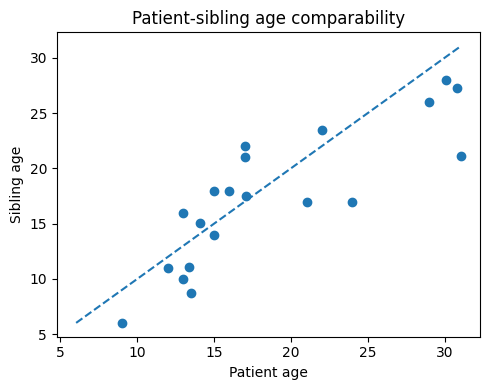

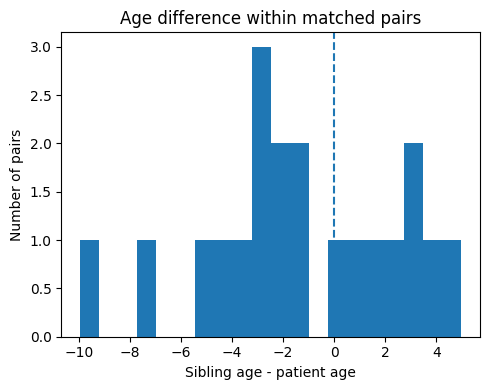

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(age_pair["Patient"], age_pair["Sibling"])
lims = [
    min(age_pair["Patient"].min(), age_pair["Sibling"].min()),
    max(age_pair["Patient"].max(), age_pair["Sibling"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Patient age")
plt.ylabel("Sibling age")
plt.title("Patient-sibling age comparability")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(age_pair["sibling_minus_patient_age"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Sibling age - patient age")
plt.ylabel("Number of pairs")
plt.title("Age difference within matched pairs")
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

downsample to comparable level

In [15]:
def downsample_per_sample_celltype(
    adata,
    sample_col="assigned_scaleplex",
    celltype_col="celltype_l1",
    max_cells_per_sample_celltype=500, # maximum number of cells to keep per sample and per cell type
    min_cells_per_sample_celltype=20, # minimum number of cells to keep per sample and per cell type
    random_state=0,
):
    rng = np.random.default_rng(random_state)
    keep = []

    obs = adata.obs.copy()

    for (sample, celltype), idx in obs.groupby([sample_col, celltype_col], observed=True).groups.items(): # iterate over each sample and cell type combination
        idx = np.array(list(idx)) # indices of cells belonging to this sample and cell type
        n = len(idx) # number of cells belonging to this sample and cell type

        if n < min_cells_per_sample_celltype:
            continue

        n_keep = min(n, max_cells_per_sample_celltype)
        keep.extend(rng.choice(idx, size=n_keep, replace=False))

    return adata[keep].copy()

In [16]:
adata_ds = downsample_per_sample_celltype(
    adata_ps,
    sample_col="assigned_scaleplex",
    celltype_col="celltype_l1",
    max_cells_per_sample_celltype=500,
    min_cells_per_sample_celltype=20,
    random_state=1,
)

print(adata_ps.shape)
print(adata_ds.shape)

pd.crosstab(
    adata_ds.obs["family_role"],
    adata_ds.obs["celltype_l1"]
)

(578284, 36910)
(124703, 36910)


celltype_l1,B cells,CD14 Mono,CD16 Mono,CD4 T,CD8 T,DC,NK,Proerythroblast
family_role,,,,,,,,
Patient,8638,9659,7148,10000,9944,2198,10000,373
Sibling,9541,11993,6459,12500,11989,1715,12500,46


In [18]:
adata_ds.write_h5ad("adata_no_doublet_anno_paired_downsampled.h5ad")

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [7]:
adata_ds=ad.read_h5ad("/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc/adata_no_doublet_anno_paired_downsampled.h5ad")

In [8]:
obs = adata_ds.obs.dropna(
    subset=["disease_group", "celltype_l1"]
).copy()

comp = pd.crosstab(
    obs["disease_group"],
    obs["celltype_l1"]
)

comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

comp_pct

celltype_l1,B cells,CD14 Mono,CD16 Mono,CD4 T,CD8 T,DC,NK,Proerythroblast
disease_group,,,,,,,,
Non-patient,14.295132,17.968926,9.677419,18.728556,17.962932,2.569558,18.728556,0.068921
Patient,14.903382,16.664941,12.332643,17.253278,17.156660,3.792271,17.253278,0.643547


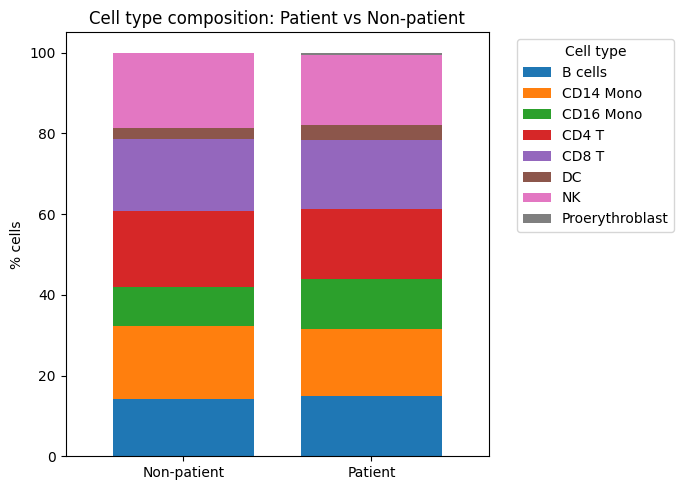

In [9]:
ax = comp_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5),
    width=0.75
)

plt.ylabel("% cells")
plt.xlabel("")
plt.title("Cell type composition: Patient vs Non-patient")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")
plt.xticks(rotation=0)
plt.tight_layout()

Calculate 22q11 gene expression across cell types and compare patients vs siblings

22q11.2DS is a contiguous gene deletion syndrome, meaning the phenotype comes from deletion of a block of neighboring genes, not only one gene. Most individuals have a recurrent deletion from LCR22A to LCR22D, historically called the 3 Mb deletion, and this region contains roughly 40–46 protein-coding genes depending on annotation/reference genome.

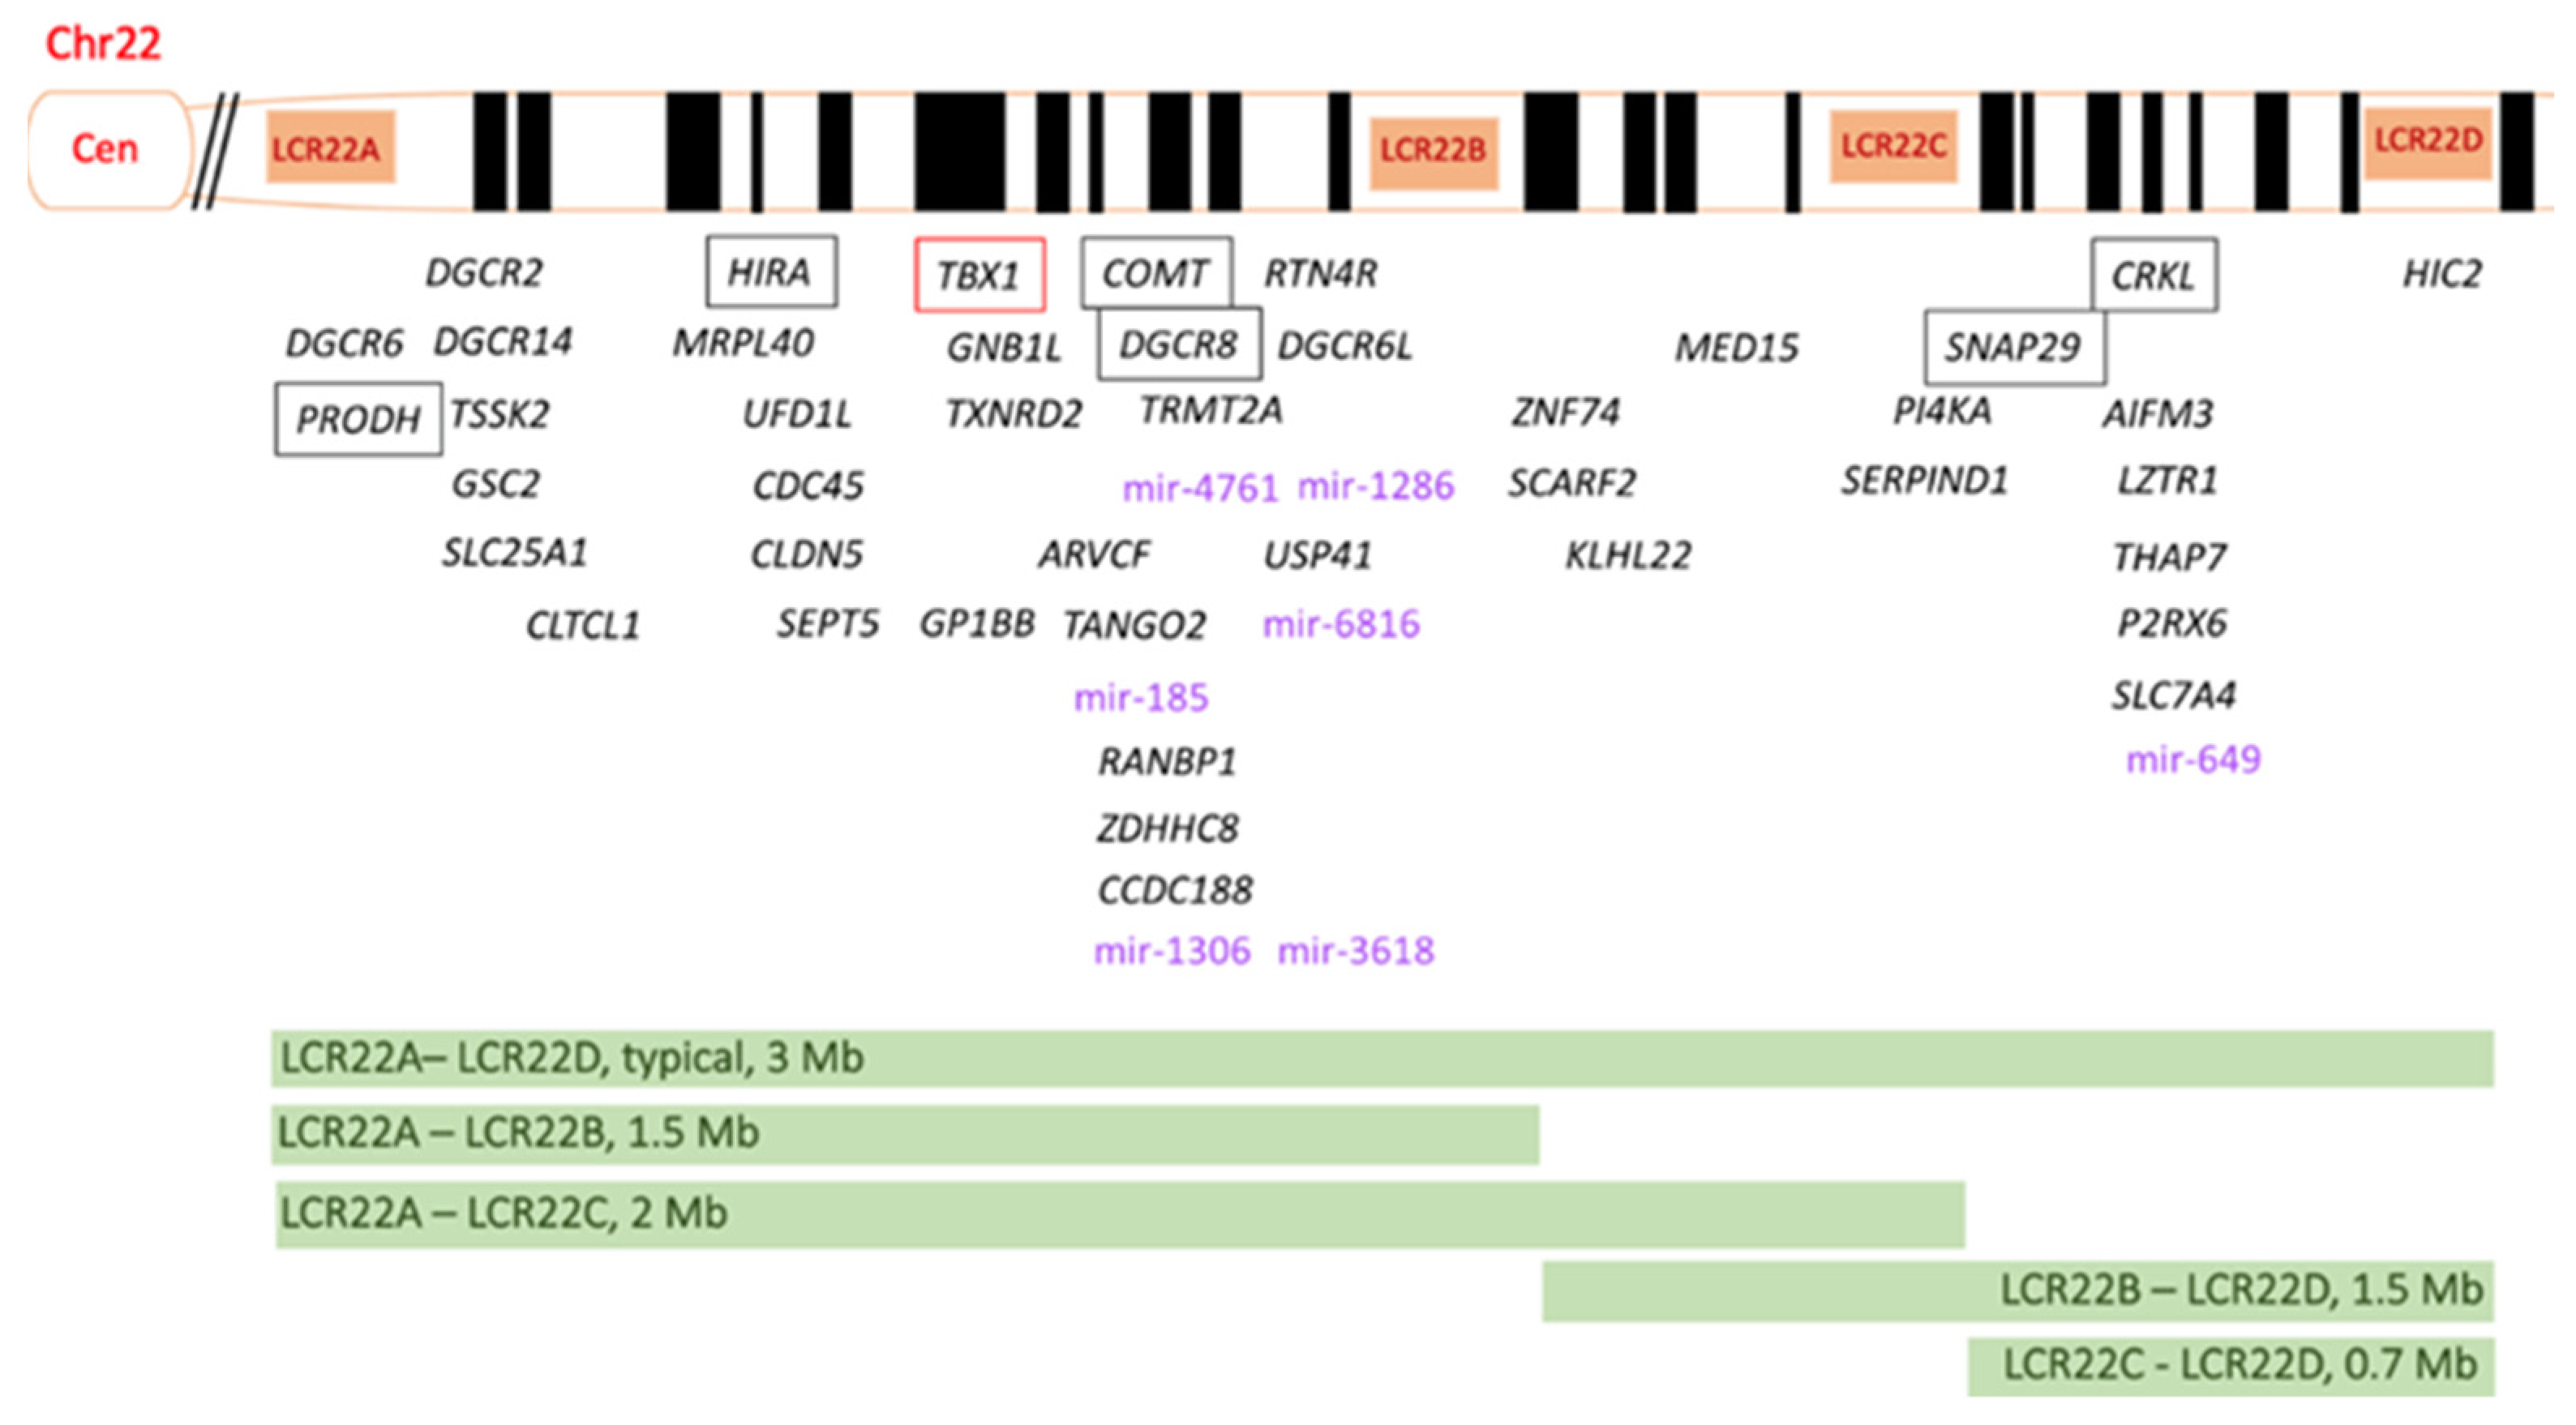

In [10]:
# Working 22q11.2-region gene list.
# These genes are located within the commonly deleted 22q11.2 interval.
# This list should be replaced or expanded using the exact deletion coordinates
# or the lab-approved 22q11.2 gene set for the study.
genes_22q11_candidate = [
    "DGCR6", "PRODH", "DGCR2", "DGCR14", "TSSK2", "GSC2",
    "SLC25A1", "CLTCL1", "HIRA", "MRPL40", "UFD1L", "CDC45",
    "CLDN5", "SEPTIN5", "GP1BB", "TBX1", "GNB1L", "TXNRD2",
    "COMT", "ARVCF", "TANGO2", "DGCR8", "TRMT2A", "RANBP1",
    "ZDHHC8", "CCDC188", "RTN4R", "DGCR6L", "USP41", "ZNF74",
    "SCARF2", "KLHL22", "MED15", "PI4KA", "SERPIND1",
    "SNAP29", "CRKL", "AIFM3", "LZTR1", "THAP7", "P2RX6",
    "SLC7A4", "HIC2"
]

genes_22q11_present = [g for g in genes_22q11_candidate if g in adata_ds.var_names]
genes_22q11_missing = sorted(set(genes_22q11_candidate) - set(genes_22q11_present))

print("Present in dataset:", len(genes_22q11_present))
print(genes_22q11_present)

print("Missing from dataset:", len(genes_22q11_missing))
print(genes_22q11_missing)

Present in dataset: 41
['DGCR6', 'PRODH', 'DGCR2', 'TSSK2', 'GSC2', 'SLC25A1', 'CLTCL1', 'HIRA', 'MRPL40', 'CDC45', 'CLDN5', 'SEPTIN5', 'GP1BB', 'TBX1', 'GNB1L', 'TXNRD2', 'COMT', 'ARVCF', 'TANGO2', 'DGCR8', 'TRMT2A', 'RANBP1', 'ZDHHC8', 'CCDC188', 'RTN4R', 'DGCR6L', 'USP41', 'ZNF74', 'SCARF2', 'KLHL22', 'MED15', 'PI4KA', 'SERPIND1', 'SNAP29', 'CRKL', 'AIFM3', 'LZTR1', 'THAP7', 'P2RX6', 'SLC7A4', 'HIC2']
Missing from dataset: 2
['DGCR14', 'UFD1L']


In [10]:
del adata_ps

NameError: name 'adata_ps' is not defined

In [11]:
adata_ds_expr = adata_ds.copy()
# Save raw counts before normalization, if not already saved
if "counts" not in adata_ds_expr.layers:
    adata_ds_expr.layers["counts"] = adata_ds_expr.X.copy()

# Normalize/log1p for expression summaries and scoring
sc.pp.normalize_total(adata_ds_expr, target_sum=1e4)
sc.pp.log1p(adata_ds_expr)

adata_ds_expr.layers["lognorm"] = adata_ds_expr.X.copy()

In [12]:
X = adata_ds_expr.layers["counts"]
vals = X.data if hasattr(X, "data") else X.ravel()

bad = vals[~np.isclose(vals, np.round(vals))]
print("number non-integer:", bad.size)
print("fraction non-integer:", bad.size / vals.size)
print("examples:", bad[:20])

number non-integer: 16274435
fraction non-integer: 0.0806326258599954
examples: [0.5      0.25     0.5      0.2      0.5      0.666667 0.5      0.666667
 0.7      0.5      0.2      0.7      0.166667 0.2      0.166667 0.166667
 0.666667 0.5      0.5      0.5     ]


In [11]:
#calculate 22q11 expression score for every cell
import scipy.sparse as sp

X22 = adata_ds_expr[:, genes_22q11_present].layers["lognorm"]

if sp.issparse(X22):
    X22_dense = X22.toarray()
else:
    X22_dense = np.asarray(X22)

adata_ds_expr.obs["mean_22q11_expr"] = X22_dense.mean(axis=1) # mean expression of 22q11 genes per cell

adata_ds_expr.obs["frac_22q11_detected"] = (X22_dense > 0).mean(axis=1) # fraction of 22q11 genes detected (non-zero expression) per cell

adata_ds_expr.obs["score_22q11"] = (
    adata_ds_expr.obs["mean_22q11_expr"] * adata_ds_expr.obs["frac_22q11_detected"] # mean expression multiplied by fraction detected
)

build control reference per cell type

In [12]:
control_label = "Sibling"
celltype_col = "celltype_l1"
group_col = "family_role"

control_obs = adata_ds_expr.obs[
    adata_ds_expr.obs[group_col] == control_label
].copy()

control_ref = (
    control_obs
    .groupby(celltype_col, observed=True)["score_22q11"]
    .agg(
        control_mean="mean",
        control_sd="std",
        control_median="median",
        control_q01=lambda x: np.quantile(x, 0.01),
        control_q05=lambda x: np.quantile(x, 0.05),
        control_q10=lambda x: np.quantile(x, 0.10),
        control_q25=lambda x: np.quantile(x, 0.25),
        control_q75=lambda x: np.quantile(x, 0.75),
        n_control_cells="size",
    )
    .reset_index()
)

display(control_ref)

,celltype_l1,control_mean,control_sd,control_median,control_q01,control_q05,control_q10,control_q25,control_q75,n_control_cells
0,B cells,0.006540,0.008015,0.004269,0.0,0.000000,0.000000,0.001173,0.009563,9541
1,CD14 Mono,0.012517,0.012383,0.009058,0.0,0.000000,0.001077,0.003798,0.017888,11993
2,CD16 Mono,0.014799,0.013455,0.011169,0.0,0.000807,0.001152,0.004350,0.021543,6459
3,CD4 T,0.008306,0.009072,0.005119,0.0,0.000000,0.000000,0.001348,0.011372,12500
4,CD8 T,0.010034,0.010437,0.006068,0.0,0.000000,0.001034,0.001591,0.014352,11989
5,DC,0.017619,0.013980,0.014526,0.0,0.001366,0.003506,0.007353,0.024394,1715
6,NK,0.011082,0.010878,0.008632,0.0,0.000000,0.001154,0.003668,0.016411,12500
7,Proerythroblast,0.013079,0.014772,0.007157,0.0,0.000000,0.001524,0.003893,0.015539,46


In [16]:
#apply control reference to patient cells
adata_ds_expr.obs = adata_ds_expr.obs.merge(
    control_ref,
    on=celltype_col,
    how="left"
)

adata_ds_expr.obs.index = adata_ds_expr.obs_names

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
#how far each cell is from its own cell-type-specific control reference.
#z = 0      similar to control average
#z < 0      lower than control
#z << 0     much lower than control
#z > 0      higher than control
adata_ds_expr.obs["score_22q11_z_vs_control"] = (
    adata_ds_expr.obs["score_22q11"] -
    adata_ds_expr.obs["control_mean"]
) / adata_ds_expr.obs["control_sd"]

In [14]:
#classify cells
adata_ds_expr.obs["patient_cell"] = (
    adata_ds_expr.obs[group_col] == "Patient"
)

adata_ds_expr.obs["below_control_q25"] = (
    adata_ds_expr.obs["score_22q11"] <
    adata_ds_expr.obs["control_q25"]
)

adata_ds_expr.obs["cell_22q11_status"] = "not_patient"

adata_ds_expr.obs.loc[
    adata_ds_expr.obs["patient_cell"] &
    adata_ds_expr.obs["below_control_q25"],
    "cell_22q11_status"
] = "22q11_low_deletion_like"

adata_ds_expr.obs.loc[
    adata_ds_expr.obs["patient_cell"] &
    ~adata_ds_expr.obs["below_control_q25"],
    "cell_22q11_status"
] = "22q11_high_control_like"

In [15]:
adata_ds_expr.obs["cell_22q11_status"].value_counts()

cell_22q11_status
not_patient                66743
22q11_low_deletion_like    32131
22q11_high_control_like    25829
Name: count, dtype: int64

In [16]:
status_table = pd.crosstab(
    adata_ds_expr.obs[celltype_col],
    adata_ds_expr.obs["cell_22q11_status"]
)

display(status_table)

cell_22q11_status,22q11_high_control_like,22q11_low_deletion_like,not_patient
celltype_l1,,,
B cells,4341,4297,9541
CD14 Mono,4237,5422,11993
CD16 Mono,3087,4061,6459
CD4 T,4874,5126,12500
CD8 T,4337,5607,11989
DC,955,1243,1715
NK,3883,6117,12500
Proerythroblast,115,258,46


In [21]:
adata_ds_expr.write_h5ad("/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc/adata_no_doublet_anno_paired_downsampled_DSexpr.h5ad")

/home/users/z/zhouji/.conda/envs/rsc-gpu/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [2]:
adata_ds_expr=ad.read_h5ad("/home/users/z/zhouji/2026_Ribierre_scalebio_pbmc/adata_no_doublet_anno_paired_downsampled_DSexpr.h5ad")

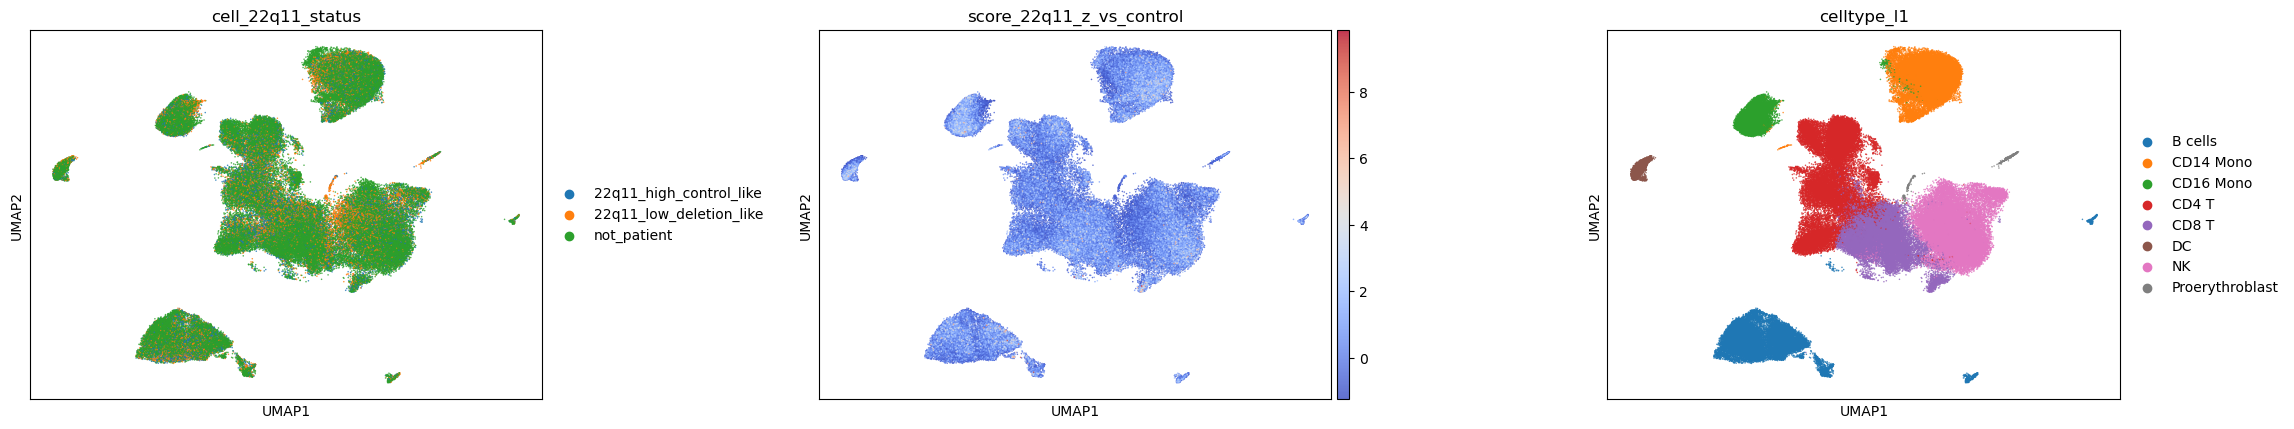

In [3]:
sc.pl.umap(adata_ds_expr, color=["cell_22q11_status", "score_22q11_z_vs_control", "celltype_l1"], s=5, ncols=3, cmap="coolwarm", size=5, alpha=0.8, wspace=0.4)

violin per cell type by sibling

expression of 22q11 genes in control dataset

In [17]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# settings
# -----------------------------
control_label = "Sibling" 
group_col = "family_role"
celltype_col = "celltype_l1"

# -----------------------------
# subset control cells
# -----------------------------
adata_ctrl = adata_ds_expr[adata_ds_expr.obs[group_col] == control_label].copy()

print(adata_ctrl)
print(adata_ctrl.obs[celltype_col].value_counts())

AnnData object with n_obs × n_vars = 66743 × 36910
    obs: 'counts', 'genes', 'totalReads', 'countedReads', 'mappedReads', 'geneReads', 'exonReads', 'intronReads', 'antisenseReads', 'mitoReads', 'countedMultiGeneReads', 'Saturation', 'mitoProp', 'PCR', 'RT', 'bead_bc', 'sample', 'flags', 'passing_scaleplex', 'assigned_scaleplex', 'sample_group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.07', 'leiden_res_0.50', 'leiden_res_1.00', 'Mono_score', 'CD4+ T_score', 'CD8+ T_score', 'NK_score', 'B cells_score', 'DC_score', 'unconventional T_score', 'Eryth_score', 'HSPC_score', 'ILC_score', 'Platelet_score', 'celltype_l1', 'Unnamed: 0', 'Date of fixation', 'Unnamed: 2', 'sample_id', 'barcode', 'sample_type', 'sample_name', 'diagnosis', 'participant_id', 'age', 'sex', 'ethnic_origin', 'linked_22q_id', 'Type of relation

In [18]:
P_label = "Patient" 
group_col = "family_role"
celltype_col = "celltype_l1"

# -----------------------------
# subset control cells
# -----------------------------
adata_P = adata_ds_expr[adata_ds_expr.obs[group_col] == P_label].copy()

print(adata_P)
print(adata_P.obs[celltype_col].value_counts())

AnnData object with n_obs × n_vars = 57960 × 36910
    obs: 'counts', 'genes', 'totalReads', 'countedReads', 'mappedReads', 'geneReads', 'exonReads', 'intronReads', 'antisenseReads', 'mitoReads', 'countedMultiGeneReads', 'Saturation', 'mitoProp', 'PCR', 'RT', 'bead_bc', 'sample', 'flags', 'passing_scaleplex', 'assigned_scaleplex', 'sample_group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res_0.07', 'leiden_res_0.50', 'leiden_res_1.00', 'Mono_score', 'CD4+ T_score', 'CD8+ T_score', 'NK_score', 'B cells_score', 'DC_score', 'unconventional T_score', 'Eryth_score', 'HSPC_score', 'ILC_score', 'Platelet_score', 'celltype_l1', 'Unnamed: 0', 'Date of fixation', 'Unnamed: 2', 'sample_id', 'barcode', 'sample_type', 'sample_name', 'diagnosis', 'participant_id', 'age', 'sex', 'ethnic_origin', 'linked_22q_id', 'Type of relation

In [19]:
# -----------------------------
# use log-normalized expression
# -----------------------------
X = adata_ctrl[:, genes_22q11_present].layers["lognorm"]

if sp.issparse(X):
    X = X.toarray()
else:
    X = np.asarray(X)

expr_df = pd.DataFrame(
    X,
    index=adata_ctrl.obs_names,
    columns=genes_22q11_present
)

expr_df[celltype_col] = adata_ctrl.obs[celltype_col].values

# mean expression per cell type
heatmap_df = (
    expr_df
    .groupby(celltype_col, observed=True)
    .mean()
    .T
)

# rows = genes, columns = cell types
display(heatmap_df.head())

celltype_l1,B cells,CD14 Mono,CD16 Mono,CD4 T,CD8 T,DC,NK,Proerythroblast
DGCR6,0.000957,0.004163,0.003740,0.002906,0.002917,0.001516,0.002002,0.000000
PRODH,0.002029,0.002508,0.003138,0.002299,0.001325,0.001644,0.001590,0.000000
DGCR2,0.386525,0.592261,0.459061,0.525636,0.438308,0.455433,0.392968,0.316672
TSSK2,0.000000,0.000082,0.000000,0.000000,0.000313,0.000000,0.000000,0.000000
GSC2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [20]:
# -----------------------------
# use log-normalized expression
# -----------------------------
X_P = adata_P[:, genes_22q11_present].layers["lognorm"]

if sp.issparse(X_P):
    X_P = X_P.toarray()
else:
    X_P = np.asarray(X_P)

expr_df_P = pd.DataFrame(
    X_P,
    index=adata_P.obs_names,
    columns=genes_22q11_present
)

expr_df_P[celltype_col] = adata_P.obs[celltype_col].values

# mean expression per cell type
heatmap_df_P = (
    expr_df_P
    .groupby(celltype_col, observed=True)
    .mean()
    .T
)

# rows = genes, columns = cell types
display(heatmap_df_P.head())

celltype_l1,B cells,CD14 Mono,CD16 Mono,CD4 T,CD8 T,DC,NK,Proerythroblast
DGCR6,0.000390,0.001305,0.002993,0.001644,0.001281,0.000000,0.000666,0.000000
PRODH,0.001287,0.002000,0.001556,0.001609,0.001125,0.003262,0.001860,0.000000
DGCR2,0.203078,0.341737,0.262794,0.293847,0.247354,0.245750,0.215098,0.173684
TSSK2,0.000000,0.000131,0.000000,0.000423,0.000165,0.000000,0.000321,0.000000
GSC2,0.000000,0.000184,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


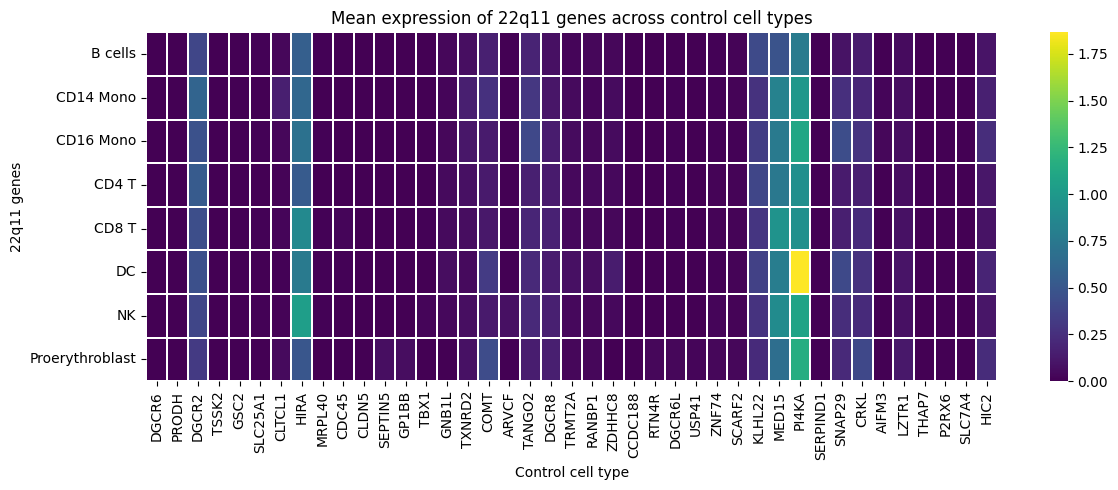

In [21]:
plt.figure(figsize=(max(8, len(heatmap_df) * 0.3), 5))
sns.heatmap(
    heatmap_df.T,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white"
)
plt.xlabel("Control cell type")
plt.ylabel("22q11 genes")
plt.title("Mean expression of 22q11 genes across control cell types")
plt.tight_layout()
plt.show()

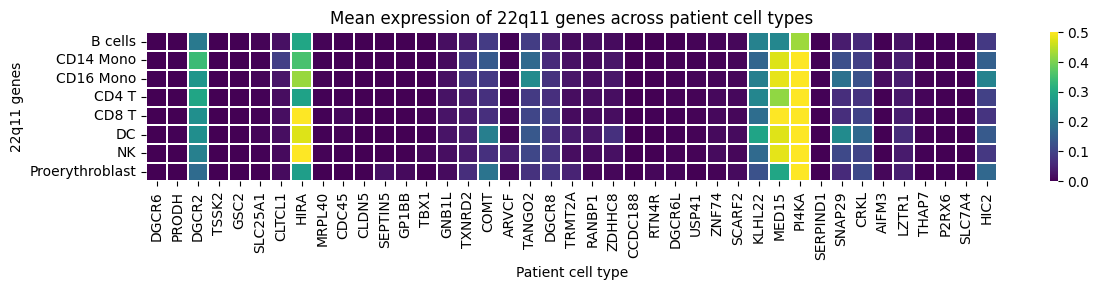

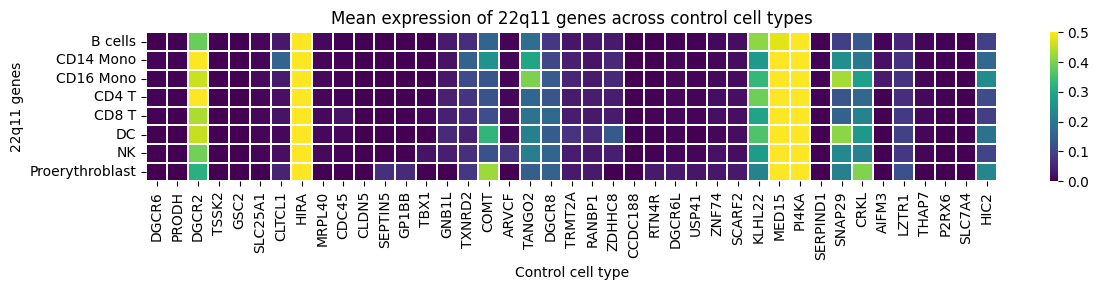

In [34]:
plt.figure(figsize=(max(8, len(heatmap_df_P) * 0.3), 3))
sns.heatmap(
    heatmap_df_P.T,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    vmin=0, vmax=0.5
)
plt.xlabel("Patient cell type")
plt.ylabel("22q11 genes")
plt.title("Mean expression of 22q11 genes across patient cell types")
plt.tight_layout()
plt.show()

plt.figure(figsize=(max(8, len(heatmap_df) * 0.3), 3))
sns.heatmap(
    heatmap_df.T,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    vmin=0, vmax=0.5
)
plt.xlabel("Control cell type")
plt.ylabel("22q11 genes")
plt.title("Mean expression of 22q11 genes across control cell types")
plt.tight_layout()
plt.show()

DGCR2, HIRA CTCL1 around 15 genes

Dispersion 

display cumulatieve plot of expression per cell type for see crop KS test/rank sum test for each p s pair

plot heatmap of standard diviation between p and s

squared coefficient of variation 

Fano factor?

best way to spot varibality 

heatmap for samples seq deeper





Violine per gene per cell type in patient and siblings 
display 
y = pairs
x = genes
color code: dispersion of genes?



#check expression in saturated sample

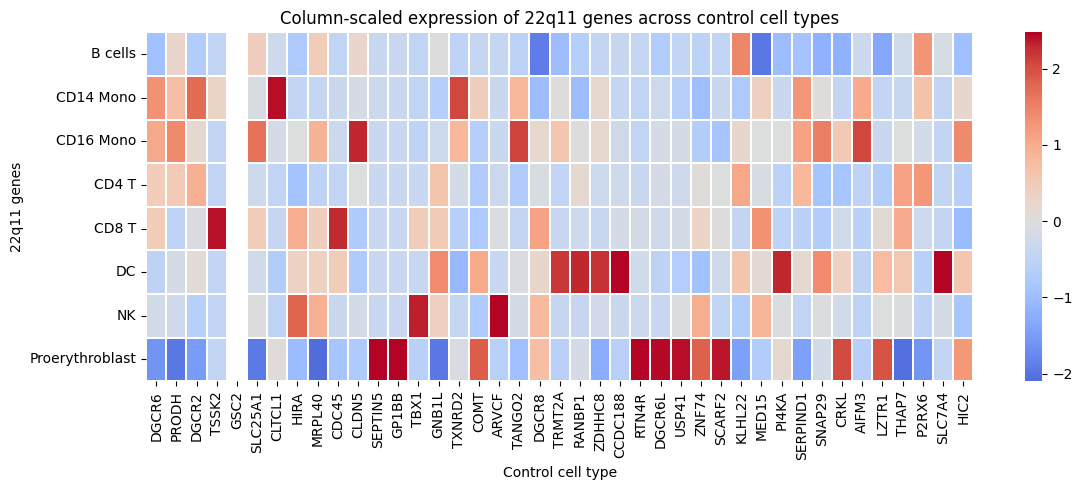

In [34]:
heatmap_z = heatmap_df.T.copy()

col_mean = heatmap_z.mean(axis=0)
col_std = heatmap_z.std(axis=0).replace(0, np.nan)

heatmap_z = heatmap_z.sub(col_mean, axis=1).div(col_std, axis=1)

plt.figure(figsize=(max(12, len(heatmap_z) * 0.3), 5))
sns.heatmap(
    heatmap_z,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="white"
)
plt.xlabel("Control cell type")
plt.ylabel("22q11 genes")
plt.title("Column-scaled expression of 22q11 genes across control cell types")
plt.tight_layout()
plt.show()

stratify patients

![ChatGPT Image Jul 9, 2026, 05_11_15 PM.png](<attachment:ChatGPT Image Jul 9, 2026, 05_11_15 PM.png>)
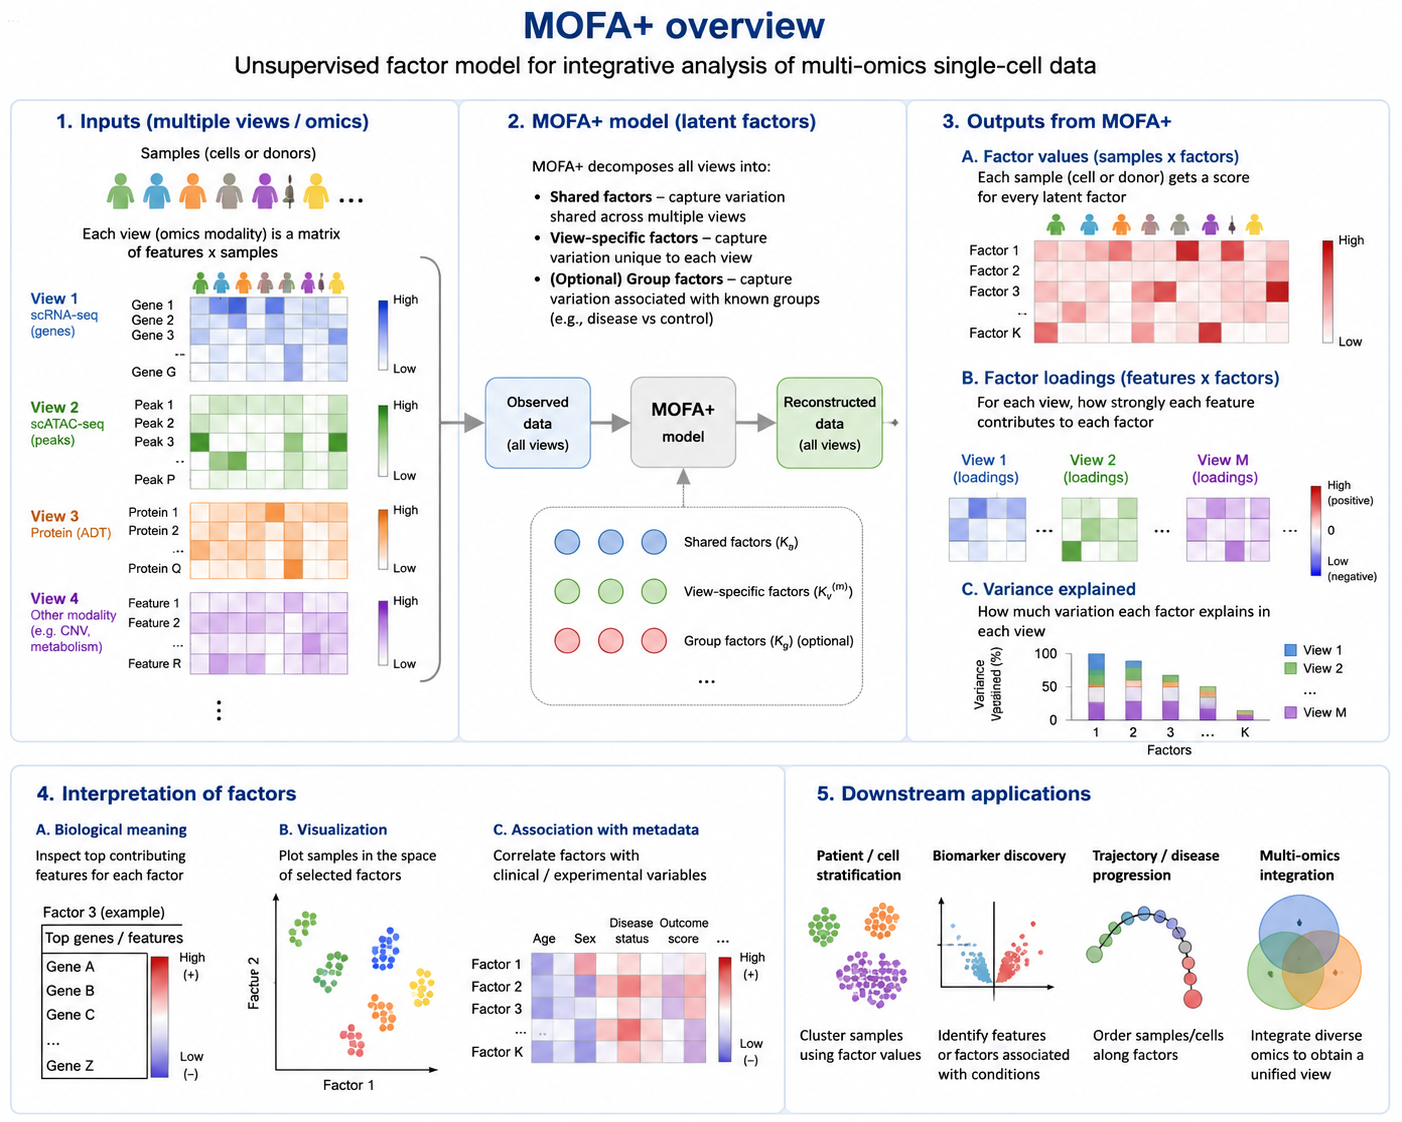

View 1: cell-type composition

View 2: CD4 T-cell transcriptomic programs

View 3: CD8 T-cell transcriptomic programs

View 4: B-cell transcriptomic programs

View 5: NK-cell transcriptomic programs

View 6: monocyte transcriptomic programs

View 7: DCtranscriptomic features

View 8: Patient info?

heatmap for patient

focus on genes most expressed

matrix of dispersion: vlnplot?


paire-wise S diviation

DEGs within patient q75 and q25 vs beween pa and sib 

attribute to remaining 22q11 genes.


